In [3]:
!pip install tensorboardX rdkit
!pip install rdkit-pypi

In [4]:
import pickle
import pandas as pd
from rdkit import Chem
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [8]:

# define the data frame to replace the smiles in the relative learning with the respective host

def prepare_data(raw_filename, target_name='Calx'):
    # Read the CSV file
    smiles_targets_df = pd.read_csv(raw_filename)
    print("Number of all SMILES:", len(smiles_targets_df))

    # Create lists to store data
    remained_smiles = []
    canonical_smiles_list = []
    atom_num_dist = []

    # Process each SMILES
    for smiles in smiles_targets_df['SMILES']:
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                atom_num_dist.append(len(mol.GetAtoms()))
                remained_smiles.append(smiles)
                canonical_smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
                canonical_smiles_list.append(canonical_smiles)
        except:
            continue

    # Create a new DataFrame with processed data
    remained_df = pd.DataFrame({
        'SMILES': remained_smiles,
        'cano_smiles': canonical_smiles_list
    })

    # Add other columns from the original DataFrame
    for col in smiles_targets_df.columns:
        if col != 'SMILES':
            remained_df[col] = smiles_targets_df[smiles_targets_df['SMILES'].isin(remained_smiles)][col].values

    return remained_df


remained_df = prepare_data('/notebooks/Codebase/Database/cal_abs.csv')



Number of all SMILES: 38


In [2]:
def process_dictionary(df, unprocessed_dict, relative_is_counter_minus_host=True):
    """
    Process the unprocessed dictionary to calculate absolute predictions for each host.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing host information with columns 'Host', 'cano_smile', and target columns
    unprocessed_dict : dict
        Dictionary with hosts as main keys, smile pairs as subkeys, and target predictions
    relative_is_counter_minus_host : bool, default=True
        If True, relative prediction is (counter - host)
        If False, relative prediction is (host - counter)
    
    Returns:
    --------
    dict
        Processed dictionary with average absolute predictions for each host and target
    """
    processed_dict = {}
    
    for host, smile_pairs in unprocessed_dict.items():
        host_smile = df.loc[df['Host'] == host, 'cano_smile'].values[0]
        processed_dict[host] = {}
        
        for smile_pair, targets in smile_pairs.items():
            # Split the pair of smiles
            smile1, smile2 = smile_pair.split(',')
            
            # Determine which smile is the host and which is the counter
            if smile1.strip() == host_smile:
                counter_smile = smile2.strip()
            elif smile2.strip() == host_smile:
                counter_smile = smile1.strip()
            else:
                # If neither smile matches the host, skip this pair
                continue
            
            counter_row = df[df['cano_smile'] == counter_smile]
            if counter_row.empty:
                continue
            
            for target_name, values in targets.items():
                if target_name not in processed_dict[host]:
                    processed_dict[host][target_name] = {'predictions': []}
                
                counter_actual = counter_row[target_name].values[0]
                relative_prediction = values['predicted']
                
                # Calculate absolute prediction for the host
                if relative_is_counter_minus_host:
                    # If relative is (counter - host), then host = counter - relative
                    host_absolute_prediction = counter_actual - relative_prediction
                else:
                    # If relative is (host - counter), then host = relative + counter
                    host_absolute_prediction = relative_prediction + counter_actual
                
                processed_dict[host][target_name]['predictions'].append(host_absolute_prediction)
        
        # Calculate average predictions for each target
        for target_name in list(processed_dict[host].keys()):
            predictions = processed_dict[host][target_name]['predictions']
            if predictions:
                processed_dict[host][target_name] = {
                    'actual': host_row[target_name],
                    'predicted': sum(predictions) / len(predictions)
                }
            else:
                # Remove targets with no predictions
                del processed_dict[host][target_name]
    
    return processed_dict
unprocessed_df= pd.read_pickle('/notebooks/Codebase/GCN/CheckPoint/RGCN_regression_unprocessed.pkl')
process_dictionary(remained_df, unprocessed_df, relative_is_counter_minus_host=True)


NameError: name 'pd' is not defined

In [3]:
# Why accounting for the reversed pairs is making the model worst! 

def compare_predictions_with_without_reversed(nested_dict, remained_df):
    abs_values_lookup = remained_df.set_index('cano_smiles').to_dict(orient='index')
    
    comparison_results = []
    
    # Loop through main SMILES in nested_dict
    for main_smiles, pairs in nested_dict.items():
        for pair, targets in pairs.items():
            smiles1, smiles2 = pair.split(',')
            
            # Determine if it's a straight or reversed pair
            if main_smiles == smiles1:
                other_smiles = smiles2
                straight = True
            else:
                other_smiles = smiles1
                straight = False
            
            if other_smiles in abs_values_lookup:
                abs_values_other = abs_values_lookup[other_smiles]
                
                # Loop through each target and calculate predicted main value
                for target, values in targets.items():
                    rel_predicted = values['predicted']
                    abs_other_value = abs_values_other[target]
                    
                    # Predicted value with correct handling of reverse
                    if straight:
                        predicted_main_with_reversed = rel_predicted + abs_other_value
                    else:
                        predicted_main_with_reversed = abs_other_value - rel_predicted
                    
                    # Predicted value without handling reverse (always adding)
                    predicted_main_without_reversed = rel_predicted + abs_other_value
                    
                    # Actual value
                    actual_value = abs_values_lookup[main_smiles][target]
                    
                    # Store comparison results
                    comparison_results.append({
                        'main_smiles': main_smiles,
                        'pair': pair,
                        'target': target,
                        'predicted_with_reversed': predicted_main_with_reversed,
                        'predicted_without_reversed': predicted_main_without_reversed,
                        'actual': actual_value,
                        'error_with_reversed': abs(predicted_main_with_reversed - actual_value),
                        'error_without_reversed': abs(predicted_main_without_reversed - actual_value)
                    })
    
    return pd.DataFrame(comparison_results)

# Compare predictions with and without handling reverse logic
comparison_df = compare_predictions_with_without_reversed(data, remained_df)
print(comparison_df)

# Calculate MAE with and without handling reverse logic
mae_with_reversed = comparison_df['error_with_reversed'].mean()
mae_without_reversed = comparison_df['error_without_reversed'].mean()

print(f"MAE with reversed: {mae_with_reversed}")
print(f"MAE without reversed: {mae_without_reversed}")


                                             main_smiles  \
0      O=C(O)c1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc...   
1      O=C(O)c1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc...   
2      O=C(O)c1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc...   
3      O=C(O)c1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc...   
4      O=C(O)c1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc...   
...                                                  ...   
24955  O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...   
24956  O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...   
24957  O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...   
24958  O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...   
24959  O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1...   

                                                    pair    target  \
0      O=C(N[C@@H](Cc1ccc(O)cc1)C(=O)O)c1ccc(-c2cc3c(...      H3K4   
1      O=C(N[C@@H](Cc1ccc(O)cc1)C(=O)O)c1ccc(-c2cc3c(...    H3K4ac   
2      O=C(N[C@@H](Cc1ccc(O)cc1)C(=O)O)c1ccc(-c2cc3c(...   H3K4me1   

In [4]:
import pandas as pd

# Function to calculate final absolute predictions for each main_SMILES
def calculate_absolute_predictions(comparison_df):
    # Group by main_smiles and target, and calculate mean predicted values
    abs_predictions_with_reversed = comparison_df.groupby(['main_smiles', 'target'])['predicted_with_reversed'].mean().reset_index()
    abs_predictions_without_reversed = comparison_df.groupby(['main_smiles', 'target'])['predicted_without_reversed'].mean().reset_index()
    
    # Merge with actual values
    actual_values = comparison_df.groupby(['main_smiles', 'target'])['actual'].mean().reset_index()
    
    # Merge both predicted DataFrames with actual values
    abs_predictions_with_reversed = pd.merge(abs_predictions_with_reversed, actual_values, on=['main_smiles', 'target'])
    abs_predictions_without_reversed = pd.merge(abs_predictions_without_reversed, actual_values, on=['main_smiles', 'target'])
    
    return abs_predictions_with_reversed, abs_predictions_without_reversed

# Calculate absolute predictions
abs_predictions_with_reversed, abs_predictions_without_reversed = calculate_absolute_predictions(comparison_df)

# Calculate MAE for absolute predictions with and without handling reversed pairs
mae_abs_with_reversed = (abs(abs_predictions_with_reversed['predicted_with_reversed'] - abs_predictions_with_reversed['actual'])).mean()
mae_abs_without_reversed = (abs(abs_predictions_without_reversed['predicted_without_reversed'] - abs_predictions_without_reversed['actual'])).mean()

print(f"MAE of absolute predictions (with reversed): {mae_abs_with_reversed}")
print(f"MAE of absolute predictions (without reversed): {mae_abs_without_reversed}")


MAE of absolute predictions (with reversed): 1.4373425649402456
MAE of absolute predictions (without reversed): 1.4196253464803643


In [5]:
# Assuming abs_predictions_with_reversed and abs_predictions_without_reversed have already been calculated

# Step 1: Merge errors for comparison
abs_predictions_with_reversed['error_with_reversed'] = abs(abs_predictions_with_reversed['predicted_with_reversed'] - abs_predictions_with_reversed['actual'])
abs_predictions_without_reversed['error_without_reversed'] = abs(abs_predictions_without_reversed['predicted_without_reversed'] - abs_predictions_without_reversed['actual'])

# Merge both DataFrames to compare errors side by side
comparison_abs_errors = pd.merge(
    abs_predictions_with_reversed[['main_smiles', 'target', 'error_with_reversed']],
    abs_predictions_without_reversed[['main_smiles', 'target', 'error_without_reversed']],
    on=['main_smiles', 'target']
)

# Step 2: Identify outliers where ignoring reversals gives smaller errors
outliers_abs_errors = comparison_abs_errors[comparison_abs_errors['error_without_reversed'] < comparison_abs_errors['error_with_reversed']]

# Step 3: Map SMILES to Host names using remained_df
# Create a dictionary for quick lookup of Host names based on cano_smiles (SMILES)
smiles_to_host = remained_df.set_index('cano_smiles')['Host'].to_dict()

# Add a new column for Host names in the outliers DataFrame
outliers_abs_errors['Host'] = outliers_abs_errors['main_smiles'].map(smiles_to_host)



# Optional: If you want to drop rows where Host name is not found (i.e., NaN values in 'Host' column)
outliers_abs_errors_cleaned = outliers_abs_errors.dropna(subset=['Host'])

# Print cleaned results (if needed)
outliers_abs_errors_cleaned['Host'].unique()


/tmp/ipykernel_482/2655901289.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_abs_errors['Host'] = outliers_abs_errors['main_smiles'].map(smiles_to_host)


array(['BM1', 'DM1', 'AM1', 'AP3', 'DO2', 'AO2', 'AP4', 'E8', 'AO1',
       'AP7', 'E6', 'E7', 'E3', 'E5', 'CP1', 'BP1', 'AP1', 'CP2', 'DP2',
       'E1', 'AM2', 'BP0', 'BH2', 'DO3', 'AH4', 'AH1', 'AP5', 'AO3',
       'AH2', 'AH3', 'AH7', 'PSC4', 'PSC6', 'P-NO2'], dtype=object)

In [6]:
# Calculate the absolute predictions.


def calculate_predicted_main_values(nested_dict, remained_df):
    results = {}
    
    # Create a lookup dictionary for absolute values from remained_df
    abs_values_lookup = remained_df.set_index('cano_smiles').to_dict(orient='index')
    
    # Loop through main SMILES in nested_dict
    for main_smiles, pairs in nested_dict.items():
        predicted_sums = {}
        counts = {}
        
        # Loop through each pair of SMILES
        for pair, targets in pairs.items():
            smiles1, smiles2 = pair.split(',')
            
            # Determine if it's a straight or reversed pair
            if main_smiles == smiles1:
                other_smiles = smiles2
                straight = True
            else:
                other_smiles = smiles1
                straight = False
            
            # Get absolute values of the other SMILES from remained_df
            if other_smiles in abs_values_lookup:
                abs_values_other = abs_values_lookup[other_smiles]
                
                # Loop through each target and calculate predicted main value
                for target, values in targets.items():
                    rel_predicted = values['predicted']
                    abs_other_value = abs_values_other[target]
                    
                    if straight:
                        predicted_main_value = rel_predicted + abs_other_value
                    else:
                        predicted_main_value = abs_other_value - rel_predicted
                    
                    # Accumulate sums and counts for averaging later
                    if target not in predicted_sums:
                        predicted_sums[target] = 0
                        counts[target] = 0
                    
                    predicted_sums[target] += predicted_main_value
                    counts[target] += 1
        
        # Average predictions for each target and store results
        results[main_smiles] = {target: predicted_sums[target] / counts[target] for target in predicted_sums}
    
    return results

# Calculate predicted main values
results = calculate_predicted_main_values(data, remained_df)
print(results)

{'O=C(O)c1ccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc(c2O)Cc2cc(S(=O)(=O)O)cc(c2O)Cc2cc(-c4ccc(C(=O)O)cc4)cc(c2O)C3)cc1': {'H3K4': 3.2458737845540018, 'H3K4ac': 4.423415952373506, 'H3K4me1': 0.27263933384928074, 'H3K4me2': -1.343631476190112, 'H3K4me3': -1.8126681738973007, 'H3K9me3': -0.9887242198671214, 'H3R2me2a': -0.5269704717340362, 'H3R2me2s': 0.9555513358626624}, 'O=C(Nc1cc2c(O)c(c1)Cc1cc(S(=O)(=O)O)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1O)C2)c1ccc(-c2ccccc2)cc1': {'H3K4': -0.49539432668278965, 'H3K4ac': 0.4692139970273224, 'H3K4me1': -2.3904447561809166, 'H3K4me2': -4.500138081674006, 'H3K4me3': -3.4425524908960674, 'H3K9me3': -1.2954264892493346, 'H3R2me2a': -1.6185198114543238, 'H3R2me2s': -1.723560275068208}, 'CC(=O)c1cccc(-c2cc3c(O)c(c2)Cc2cc(S(=O)(=O)O)cc(c2O)Cc2cc(-c4cccc(C(C)=O)c4)cc(c2O)Cc2cc(S(=O)(=O)O)cc(c2O)C3)c1': {'H3K4': -1.1453067143335622, 'H3K4ac': -0.28793269556861695, 'H3K4me1': -0.7730002694756226, 'H3K4me2': -2.089378650362726, 'H3K4me3': -2.431861

In [7]:
def process_results_with_host_and_actuals(results, remained_df):
    # Create a dictionary to map SMILES to Host
    smiles_to_host = dict(zip(remained_df['cano_smiles'], remained_df['Host']))

    # Dictionary to store processed results
    processed_results = {}

    # Iterate over each main_SMILES (now we will replace with Host)
    for main_smiles, target_dict in results.items():
        # Get the corresponding Host for this main_smiles
        host = smiles_to_host.get(main_smiles, main_smiles)  # Default to main_smiles if not found

        # Initialize a new dictionary for this host
        processed_results[host] = {}

        # Iterate over each target and add predicted and actual values
        for target, predicted_value in target_dict.items():
            # Get the actual value from remained_df for this main_smiles and target
            try:
                actual_value = remained_df.loc[remained_df['cano_smiles'] == main_smiles, target].values[0]
            except IndexError:
                print(f"Warning: Actual value for {main_smiles} and {target} not found")
                actual_value = None

            # Store both predicted and actual values in the result
            processed_results[host][target] = {
                'predicted': predicted_value,
                'actual': actual_value
            }

    return processed_results


# Process the results by replacing SMILES with Host and adding actual values
processed_results = process_results_with_host_and_actuals(results, remained_df)

# Output processed results
processed_results


{'DP2': {'H3K4': {'predicted': 3.2458737845540018, 'actual': -0.356674944},
  'H3K4ac': {'predicted': 4.423415952373506, 'actual': 0.09531018},
  'H3K4me1': {'predicted': 0.27263933384928074, 'actual': -1.386294361},
  'H3K4me2': {'predicted': -1.343631476190112, 'actual': -2.302585093},
  'H3K4me3': {'predicted': -1.8126681738973007, 'actual': -3.244193633},
  'H3K9me3': {'predicted': -0.9887242198671214, 'actual': -2.645075402},
  'H3R2me2a': {'predicted': -0.5269704717340362, 'actual': -2.430418465},
  'H3R2me2s': {'predicted': 0.9555513358626624, 'actual': -1.347073648}},
 'E3': {'H3K4': {'predicted': -0.49539432668278965, 'actual': 0.09531018},
  'H3K4ac': {'predicted': 0.4692139970273224, 'actual': 0.993251773},
  'H3K4me1': {'predicted': -2.3904447561809166, 'actual': -1.049822124},
  'H3K4me2': {'predicted': -4.500138081674006, 'actual': -2.995732274},
  'H3K4me3': {'predicted': -3.4425524908960674, 'actual': -2.488914671},
  'H3K9me3': {'predicted': -1.2954264892493346, 'actua

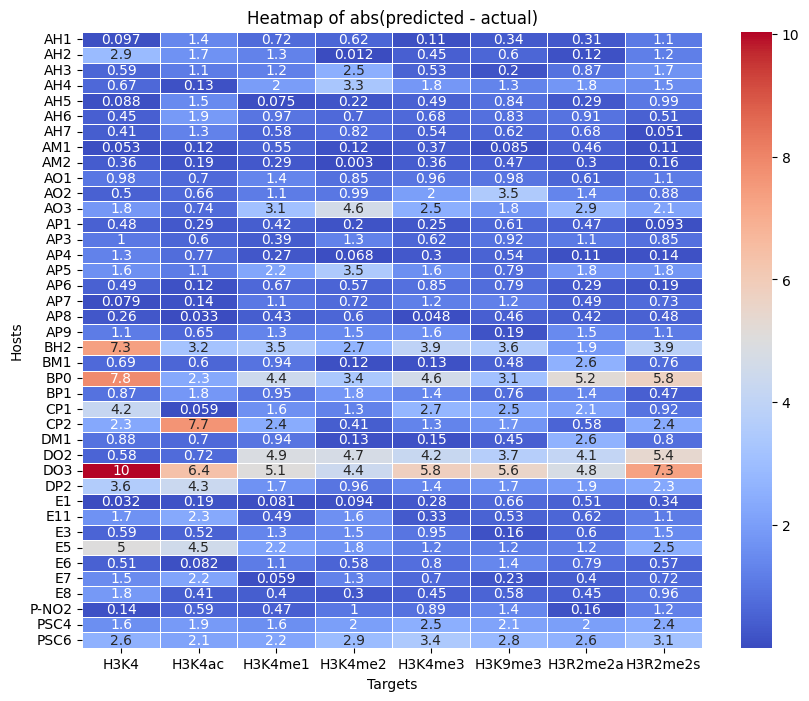

In [8]:
def create_heatmap(processed_results):
    # Initialize a dictionary to store abs(predicted - actual) for each host and target
    data = {}

    # Iterate over each host in processed_results
    for host, target_dict in processed_results.items():
        # Initialize a dictionary for this host
        data[host] = {}
        
        # Iterate over each target and calculate abs(predicted - actual)
        for target, values in target_dict.items():
            predicted = values['predicted']
            actual = values['actual']
            
            # Calculate abs(predicted - actual)
            if actual is not None:
                diff = abs(predicted - actual)
            else:
                diff = None  # Handle cases where actual value is missing
            
            # Store the difference in the dictionary
            data[host][target] = diff

    # Convert the dictionary to a Pandas DataFrame
    df = pd.DataFrame(data).T  # Transpose so that hosts are rows and targets are columns

    # Sort the DataFrame by index (hosts) alphabetically
    df = df.sort_index()

    # Create the heatmap using Seaborn
    plt.figure(figsize=(10, 8))  # Adjust figure size if needed
    sns.heatmap(df, annot=True, cmap="coolwarm", cbar=True, linewidths=0.5)

    # Add labels and title
    plt.title('Heatmap of abs(predicted - actual)')
    plt.xlabel('Targets')
    plt.ylabel('Hosts')

    # Show the heatmap
    plt.show()

# Example usage:
# Assuming `processed_results` is your final dictionary with predicted and actual values

# Call the function to create the heatmap
create_heatmap(processed_results)

In [9]:
with open('/notebooks/Result_dicts/Relative_FP.pkl', 'wb') as f:
    pickle.dump(processed_results, f)



In [9]:
def calculate_mae(final_results):
    y_true = []
    y_pred = []
    
    for host_data in final_results.values():
        for target_data in host_data.values():
            y_true.append(target_data['actual'])
            y_pred.append(target_data['predicted'])
    
    mae_score = mean_absolute_error(y_true, y_pred)
    return mae_score

# Calculate MAE across all targets/hosts
mae_score = calculate_mae(processed_results)
print(f"Mean Absolute Error (MAE): {mae_score}")

Mean Absolute Error (MAE): 1.458871728288499


In [10]:
# Math to get the absulote predictions
# Iterate over each key in the main dictionary
for main_key, first_value in data.items():
    print(f"Processing main SMILES: {main_key}")

    # Initialize a dictionary to store cumulative predictions for averaging
    cumulative_predictions = {target: 0 for target in remained_df.columns if target != 'cano_smiles'}
    count = 0

    # Iterate over each SMILES pair in the 'first_value' dictionary
    for smiles_pair, target_data in first_value.items():
        # Split the SMILES pair into two individual SMILES
        smiles1, smiles2 = smiles_pair.split(',')

        # Determine which SMILES is unique
        if smiles1 == main_key:
            unique_smile = smiles2
        elif smiles2 == main_key:
            unique_smile = smiles1
        else:
            continue

        # Retrieve known values for the unique SMILE from remained_df
        known_values = remained_df.loc[remained_df['cano_smiles'] == unique_smile].squeeze()

        # Calculate predicted values for the main_key using the formula
        for target, values in target_data.items():
            predicted_value = known_values[target] + values['predicted']
            cumulative_predictions[target] += predicted_value

        count += 1

    # Calculate average predictions for each target
    average_predictions = {target: cumulative_predictions[target] / count for target in cumulative_predictions}

    # Retrieve actual values for the main_key from remained_df
    actual_values = remained_df.loc[remained_df['cano_smiles'] == main_key].squeeze()

    # Print comparison of average predictions and actual values
    print("Comparison of Average Predictions and Actual Values:")
    for target in average_predictions:
        print(f"{target}: Predicted = {average_predictions[target]}, Actual = {actual_values[target]}")
    
    print("-" * 50)  # Separator between different main_keys

Processing main SMILES: O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(-c3cccnc3)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1O)Cc1cc(-c3cccnc3)cc(c1O)C2
Comparison of Average Predictions and Actual Values:
SMILES: Predicted = 0.0, Actual = OC1=C(C=C(C2=CC=CN=C2)C=C1CC3=C(C(C4)=CC(S(=O)(O)=O)=C3)O)CC5=CC(S(=O)(O)=O)=CC(CC6=CC(C7=CN=CC=C7)=CC4=C6O)=C5O
Host: Predicted = 0.0, Actual = BH2
H3K4: Predicted = 1.2902556150062563, Actual = 4.605170186
H3K4ac: Predicted = 1.828513153555691, Actual = 0.693147181
H3K4me1: Predicted = 0.021302139235499673, Actual = 1.386294361
H3K4me2: Predicted = -1.6816740277432218, Actual = -0.385662481
H3K4me3: Predicted = -1.985773215394249, Actual = 0.741937345
H3K9me3: Predicted = -1.1795631662558717, Actual = 1.386294361
H3R2me2a: Predicted = -0.5721919355826193, Actual = 0.587786665
H3R2me2s: Predicted = 0.3272588896476495, Actual = 1.410986974
--------------------------------------------------
Processing main SMILES: O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(-c3ccccc3)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1

In [51]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

# Assuming 'data' and 'remained_df' are already defined

# Lists to store all actual and predicted values
all_actual = []
all_predicted = []

# Iterate over each key in the main dictionary
for main_key, first_value in data.items():
    # Find the corresponding Host for the main SMILES
    host_row = remained_df[remained_df['cano_smiles'] == main_key]
    if not host_row.empty:
        host = host_row['Host'].values[0]
        print(f"Processing main SMILES: {main_key}")
        print(f"Corresponding Host: {host}")
    else:
        print(f"Processing main SMILES: {main_key}")
        print("Corresponding Host not found in remained_df")

    # Initialize a dictionary to store cumulative predictions for averaging
    cumulative_predictions = {target: 0 for target in remained_df.columns if target != 'cano_smiles'}
    count = 0

    # Iterate over each SMILES pair in the 'first_value' dictionary
    for smiles_pair, target_data in first_value.items():
        # Split the SMILES pair into two individual SMILES
        smiles1, smiles2 = smiles_pair.split(',')

        # Determine which SMILES is unique
        if smiles1 == main_key:
            unique_smile = smiles2
        elif smiles2 == main_key:
            unique_smile = smiles1
        else:
            continue

        # Retrieve known values for the unique SMILE from remained_df
        known_values = remained_df.loc[remained_df['cano_smiles'] == unique_smile].squeeze()

        # Calculate predicted values for the main_key using the formula
        for target, values in target_data.items():
            predicted_value = known_values[target] + values['predicted']
            cumulative_predictions[target] += predicted_value

        count += 1

    # Calculate average predictions for each target
    average_predictions = {target: cumulative_predictions[target] / count for target in cumulative_predictions}

    # Retrieve actual values for the main_key from remained_df
    actual_values = remained_df.loc[remained_df['cano_smiles'] == main_key].squeeze()

    # Print comparison of average predictions and actual values
    print("Comparison of Average Predictions and Actual Values:")
    for target in average_predictions:
        if isinstance(actual_values[target], (int, float)):  # Check if the value is numeric
            print(f"{target}: Predicted = {average_predictions[target]}, Actual = {actual_values[target]}")
            
            # Append to overall lists for R² calculation
            all_predicted.append(average_predictions[target])
            all_actual.append(actual_values[target])
        else:
            print(f"{target}: Skipped (non-numeric value)")
    
    print("-" * 50)  # Separator between different main_keys

# Calculate overall R²
if all_actual and all_predicted:  # Check if lists are not empty
    overall_r2 = r2_score(all_actual, all_predicted)
    print(f"Overall R² score: {overall_r2}")
else:
    print("No numeric data available for R² calculation")


Processing main SMILES: O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(-c3cccnc3)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1O)Cc1cc(-c3cccnc3)cc(c1O)C2
Corresponding Host: BH2
Comparison of Average Predictions and Actual Values:
SMILES: Skipped (non-numeric value)
Host: Skipped (non-numeric value)
H3K4: Predicted = -2.023741404553652, Actual = 4.605170186
H3K4ac: Predicted = -1.6145652482054869, Actual = 0.693147181
H3K4me1: Predicted = -1.8221234277159346, Actual = 1.386294361
H3K4me2: Predicted = -2.9092618644183763, Actual = -0.385662481
H3K4me3: Predicted = -3.2568873104845406, Actual = 0.741937345
H3K9me3: Predicted = -2.037108704082214, Actual = 1.386294361
H3R2me2a: Predicted = -1.667801692581147, Actual = 0.587786665
H3R2me2s: Predicted = -2.1979364098807, Actual = 1.410986974
--------------------------------------------------
Processing main SMILES: O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(-c3ccccc3)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1O)Cc1cc(-c3ccccc3)cc(c1O)C2
Corresponding Host: BP0
Comparison of Average Predictions and A

In [21]:

# Assuming 'data' and 'remained_df' are already defined

# Initialize the nested dictionary to store results
results_dict = {}

# Lists to store all actual and predicted values for overall R² calculation
all_actual = []
all_predicted = []

# Iterate over each key in the main dictionary
for main_key, first_value in data.items():
    # Find the corresponding Host for the main SMILES
    host_row = remained_df[remained_df['cano_smiles'] == main_key]
    if not host_row.empty:
        host = host_row['Host'].values[0]
        print(f"Processing main SMILES: {main_key}")
        print(f"Corresponding Host: {host}")
    else:
        print(f"Processing main SMILES: {main_key}")
        print("Corresponding Host not found in remained_df")
        continue  # Skip this iteration if host is not found

    # Initialize the nested dictionary for this host
    results_dict[host] = {}

    # Initialize a dictionary to store cumulative predictions for averaging
    cumulative_predictions = {target: 0 for target in remained_df.columns if target != 'cano_smiles'}
    count = 0

    # Iterate over each SMILES pair in the 'first_value' dictionary
    for smiles_pair, target_data in first_value.items():
        # Split the SMILES pair into two individual SMILES
        smiles1, smiles2 = smiles_pair.split(',')

        # Determine which SMILES is unique
        if smiles1 == main_key:
            unique_smile = smiles2
        elif smiles2 == main_key:
            unique_smile = smiles1
        else:
            continue

        # Retrieve known values for the unique SMILE from remained_df
        known_values = remained_df.loc[remained_df['cano_smiles'] == unique_smile].squeeze()

        # Calculate predicted values for the main_key using the formula
        for target, values in target_data.items():
            predicted_value = known_values[target] + values['predicted']
            cumulative_predictions[target] += predicted_value

        count += 1

    # Calculate average predictions for each target
    average_predictions = {target: cumulative_predictions[target] / count for target in cumulative_predictions}

    # Retrieve actual values for the main_key from remained_df
    actual_values = remained_df.loc[remained_df['cano_smiles'] == main_key].squeeze()

    # Print comparison of average predictions and actual values
    print("Comparison of Average Predictions and Actual Values:")
    for target in average_predictions:
        if isinstance(actual_values[target], (int, float)):  # Check if the value is numeric
            print(f"{target}: Predicted = {average_predictions[target]}, Actual = {actual_values[target]}")
            
            # Append to overall lists for R² calculation
            all_predicted.append(average_predictions[target])
            all_actual.append(actual_values[target])

            # Add to the nested dictionary
            results_dict[host][target] = {
                'actual': actual_values[target],
                'predicted': average_predictions[target]
            }
        else:
            print(f"{target}: Skipped (non-numeric value)")
    
    print("-" * 50)  # Separator between different main_keys

# Calculate overall R²
if all_actual and all_predicted:  # Check if lists are not empty
    overall_r2 = r2_score(all_actual, all_predicted)
    print(f"Overall R² score: {overall_r2}")
else:
    print("No numeric data available for R² calculation")

# Save the nested dictionary to a file using pickle
#with open('Relative_FP_Processed.pkl', 'wb') as f:
#    pickle.dump(results_dict, f)

print("Results saved to Relative_FP_Processed.pkl")


Processing main SMILES: O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(-c3cccnc3)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1O)Cc1cc(-c3cccnc3)cc(c1O)C2
Corresponding Host: BH2
Comparison of Average Predictions and Actual Values:
SMILES: Skipped (non-numeric value)
Host: Skipped (non-numeric value)
H3K4: Predicted = -2.023741404553652, Actual = 4.605170186
H3K4ac: Predicted = -1.6145652482054869, Actual = 0.693147181
H3K4me1: Predicted = -1.8221234277159346, Actual = 1.386294361
H3K4me2: Predicted = -2.9092618644183763, Actual = -0.385662481
H3K4me3: Predicted = -3.2568873104845406, Actual = 0.741937345
H3K9me3: Predicted = -2.037108704082214, Actual = 1.386294361
H3R2me2a: Predicted = -1.667801692581147, Actual = 0.587786665
H3R2me2s: Predicted = -2.1979364098807, Actual = 1.410986974
--------------------------------------------------
Processing main SMILES: O=S(=O)(O)c1cc2c(O)c(c1)Cc1cc(-c3ccccc3)cc(c1O)Cc1cc(S(=O)(=O)O)cc(c1O)Cc1cc(-c3ccccc3)cc(c1O)C2
Corresponding Host: BP0
Comparison of Average Predictions and A

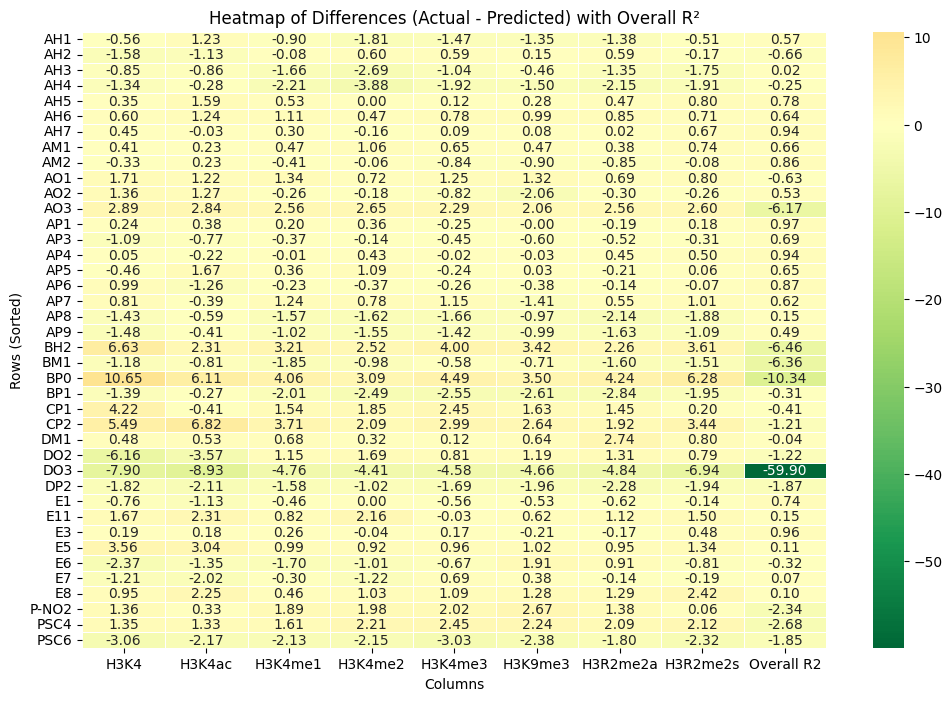

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Step 1: Prepare the data for the heatmap
rows = sorted(results_dict.keys())  # Alphabetically sorted rows
columns = list(next(iter(results_dict.values())).keys())  # Get sb keys (columns)

# Create an empty DataFrame to store the differences (actual - predicted)
diff_df = pd.DataFrame(index=rows, columns=columns)

# Create a list to store R2 scores for each row
r2_scores = []

# Step 2: Populate the DataFrame with differences and calculate R² for each row
for row in rows:
    actual_values = []
    predicted_values = []
    
    for col in columns:
        actual = results_dict[row][col]['actual']
        predicted = results_dict[row][col]['predicted']
        diff_df.loc[row, col] = actual - predicted
        
        # Collect actual and predicted values for R² calculation
        actual_values.append(actual)
        predicted_values.append(predicted)
    
    # Calculate R² score for this row across all columns
    r2 = r2_score(actual_values, predicted_values)
    r2_scores.append(r2)

# Step 3: Add an additional column "Overall R2" to the DataFrame
diff_df['Overall R2'] = r2_scores

# Convert all values to numeric (for proper heatmap visualization)
diff_df = diff_df.apply(pd.to_numeric)

# Step 4: Plot the heatmap using seaborn with a diverging color map where 0 is green and deviations are red
plt.figure(figsize=(12, 8))
sns.heatmap(diff_df, annot=True, cmap='RdYlGn_r', center=0, fmt='.2f', linewidths=0.5)

# Add labels and title
plt.title('Heatmap of Differences (Actual - Predicted) with Overall R²')
plt.ylabel('Rows (Sorted)')
plt.xlabel('Columns')

# Show plot
plt.show()


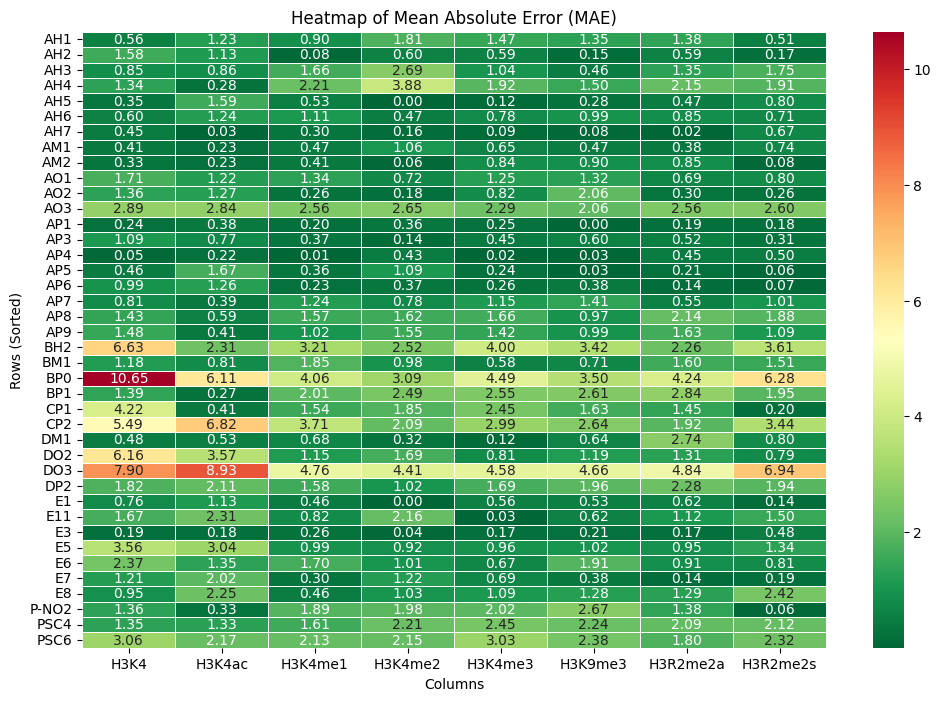

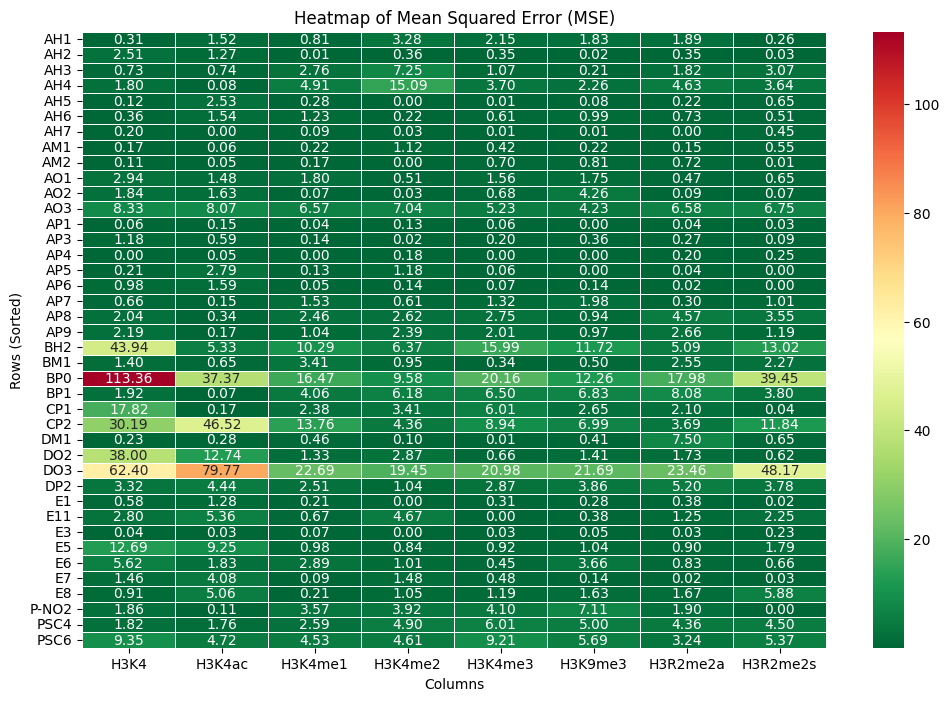

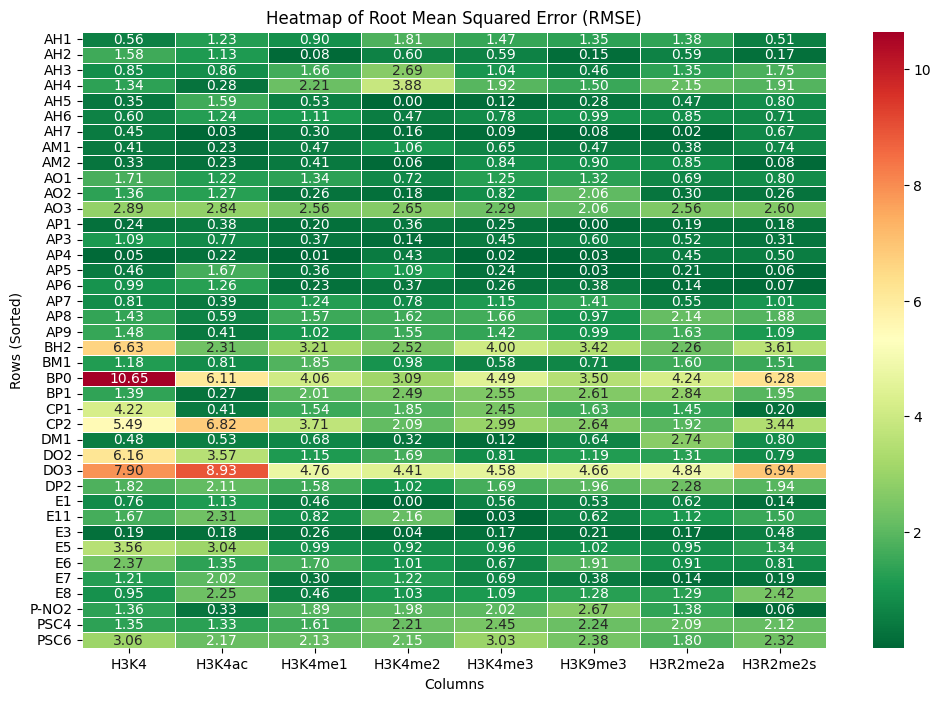

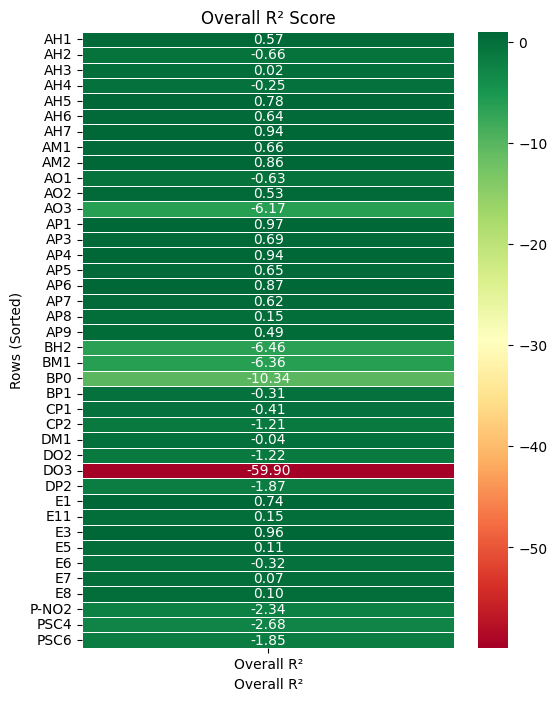

In [54]:

# Step 1: Prepare the data for metrics calculation
rows = sorted(results_dict.keys())  # Alphabetically sorted rows
columns = list(next(iter(results_dict.values())).keys())  # Get sb keys (columns)

# Create empty DataFrames to store MAE, MSE, RMSE, and R²
mae_df = pd.DataFrame(index=rows, columns=columns)
mse_df = pd.DataFrame(index=rows, columns=columns)
rmse_df = pd.DataFrame(index=rows, columns=columns)
r2_df = pd.DataFrame(index=rows, columns=["Overall R²"])

# Step 2: Populate the DataFrames with metrics
for row in rows:
    actual_values = []
    predicted_values = []
    
    for col in columns:
        actual = results_dict[row][col]['actual']
        predicted = results_dict[row][col]['predicted']
        
        # Store values for overall R² calculation
        actual_values.append(actual)
        predicted_values.append(predicted)
        
        # Calculate MAE, MSE, RMSE for each cell
        mae_df.loc[row, col] = abs(actual - predicted)
        mse_df.loc[row, col] = (actual - predicted) ** 2
        rmse_df.loc[row, col] = np.sqrt((actual - predicted) ** 2)

    # Calculate overall R² score for this row across all columns
    r2_df.loc[row] = r2_score(actual_values, predicted_values)

# Convert all values to numeric for proper heatmap visualization
mae_df = mae_df.apply(pd.to_numeric)
mse_df = mse_df.apply(pd.to_numeric)
rmse_df = rmse_df.apply(pd.to_numeric)

# Step 3: Plot heatmaps using seaborn for each metric

# MAE Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(mae_df, annot=True, cmap='RdYlGn_r', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Mean Absolute Error (MAE)')
plt.ylabel('Rows (Sorted)')
plt.xlabel('Columns')
plt.show()

# MSE Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(mse_df, annot=True, cmap='RdYlGn_r', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Mean Squared Error (MSE)')
plt.ylabel('Rows (Sorted)')
plt.xlabel('Columns')
plt.show()

# RMSE Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(rmse_df, annot=True, cmap='RdYlGn_r', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Root Mean Squared Error (RMSE)')
plt.ylabel('Rows (Sorted)')
plt.xlabel('Columns')
plt.show()

# Overall R² Heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(r2_df.astype(float), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Overall R² Score')
plt.ylabel('Rows (Sorted)')
plt.xlabel('Overall R²')
plt.show()


In [10]:

#with open('Relative_FP_Processed.pkl', 'rb') as f:
#    loaded_results = pickle.load(f)
#loaded_results

{'DP2': {'H3K4': {'actual': -0.356674944, 'predicted': 1.0684869244057356},
  'H3K4ac': {'actual': 0.09531018, 'predicted': 1.651952623162245},
  'H3K4me1': {'actual': -1.386294361, 'predicted': -0.11802949958797562},
  'H3K4me2': {'actual': -2.302585093, 'predicted': -1.7764732286787557},
  'H3K4me3': {'actual': -3.244193633, 'predicted': -1.8351533815531502},
  'H3K9me3': {'actual': -2.645075402, 'predicted': -0.8976761021520204},
  'H3R2me2a': {'actual': -2.430418465, 'predicted': -0.5055448470216901},
  'H3R2me2s': {'actual': -1.347073648, 'predicted': 0.2594068230797861}},
 'CP2': {'H3K4': {'actual': 4.605170186, 'predicted': 0.8524772912129978},
  'H3K4ac': {'actual': 6.907755279, 'predicted': 1.2637056620212848},
  'H3K4me1': {'actual': 1.824549292, 'predicted': -0.23011162096953752},
  'H3K4me2': {'actual': -1.30933332, 'predicted': -1.8351801266447525},
  'H3K4me3': {'actual': -0.562118918, 'predicted': -1.964751204311719},
  'H3K9me3': {'actual': 0.182321557, 'predicted': -1.

In [28]:
import pickle
from sklearn.metrics import r2_score
import numpy as np

# Load the dictionary
#with open('Relative_FP.pkl', 'rb') as f:
#    results_dict = pickle.load(f)
results_dict
# Initialize dictionaries to store actual and predicted values for each target
target_actuals = {}
target_predictions = {}

# Collect actual and predicted values for each target
for host, targets in results_dict.items():
    for target, values in targets.items():
        if target not in target_actuals:
            target_actuals[target] = []
            target_predictions[target] = []
        
        target_actuals[target].append(values['actual'])
        target_predictions[target].append(values['predicted'])

# Calculate R² for each target
target_r2_scores = {}
all_actuals = []
all_predictions = []

for target in target_actuals:
    actuals = np.array(target_actuals[target])
    predictions = np.array(target_predictions[target])
    
    # Remove any NaN values
    mask = ~np.isnan(actuals) & ~np.isnan(predictions)
    actuals = actuals[mask]
    predictions = predictions[mask]
    
    if len(actuals) > 0:
        r2 = r2_score(actuals, predictions)
        target_r2_scores[target] = r2
        print(f"R² score for {target}: {r2}")
        
        all_actuals.extend(actuals)
        all_predictions.extend(predictions)

# Calculate overall R² score
overall_r2 = r2_score(all_actuals, all_predictions)
print(f"\nOverall R² score: {overall_r2}")

# Print summary statistics
print("\nSummary Statistics:")
print(f"Number of targets: {len(target_r2_scores)}")
print(f"Average R² score: {np.mean(list(target_r2_scores.values()))}")
print(f"Median R² score: {np.median(list(target_r2_scores.values()))}")
print(f"Min R² score: {min(target_r2_scores.values())} ({min(target_r2_scores, key=target_r2_scores.get)})")
print(f"Max R² score: {max(target_r2_scores.values())} ({max(target_r2_scores, key=target_r2_scores.get)})")


NameError: name 'results_dict' is not defined

In [1]:
!ls

AttentiveFP		       GCN_holdout.ipynb
CheckPoint		       GCN_regression.ipynb
GCN			       RelativeGCN_Holdout.ipynb
GCN_Classification.ipynb       Relative_Processing.ipynb
GCN_Hyperparameter.ipynb       model_param
GCN_Relative_Regression.ipynb


In [2]:
!zip -r archive.zip *

  adding: AttentiveFP/ (stored 0%)
  adding: AttentiveFP/getFeatures.py (deflated 80%)
  adding: AttentiveFP/AttentiveLayers_viz.py (deflated 81%)
  adding: AttentiveFP/__init__.py (deflated 48%)
  adding: AttentiveFP/Featurizer_aromaticity_rm.py (deflated 69%)
  adding: AttentiveFP/getFeatures_aromaticity_rm.py (deflated 80%)
  adding: AttentiveFP/Featurizer.py (deflated 70%)
  adding: AttentiveFP/__pycache__/ (stored 0%)
  adding: AttentiveFP/__pycache__/Featurizer.cpython-310.pyc (deflated 42%)
  adding: AttentiveFP/__pycache__/__init__.cpython-311.pyc (deflated 40%)
  adding: AttentiveFP/__pycache__/Featurizer.cpython-311.pyc (deflated 50%)
  adding: AttentiveFP/__pycache__/AttentiveLayers.cpython-311.pyc (deflated 56%)
  adding: AttentiveFP/__pycache__/getFeatures.cpython-311.pyc (deflated 61%)
  adding: AttentiveFP/__pycache__/AttentiveLayers_viz.cpython-310.pyc (deflated 51%)
  adding: AttentiveFP/__pycache__/Featurizer_aromaticity_rm.cpython-310.pyc (deflated 42%)
  adding: Att